In [1]:
import warnings
warnings.filterwarnings('ignore')

## Review Score Prediciton using NLP and Machine Learning

Bu projede kullanıcı yorumlarından 1-5 arası puan tahmini yapmak amacıyla NLP teknikleri ve çeşitli makine öğrenmesi algoritmaları kullanılmıştır.

Öncelikle metinler temizlenmiş, POS tagging destekli lemmatization uygulanmış ve Word2Vec ile vektör temsilleri oluşturulmuştur. Ardından çeşitli sınıflandırma modelleri karşılaştırılmıştır.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet
from nltk.sentiment.vader import SentimentIntensityAnalyzer

## Data Set
veri seti 19896 satırdan oluşmaktadır. Her satır bir kullanıcı yorumu ile buna karşılık gelen puanı içermektedir.

In [3]:
df = pd.read_csv("YelpData.csv")

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19896 entries, 0 to 19895
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Yelp URL     19896 non-null  object
 1   Rating       19896 non-null  int64 
 2   Date         19896 non-null  object
 3   Review Text  19896 non-null  object
dtypes: int64(1), object(3)
memory usage: 621.9+ KB


#### Unbalanced Data

In [5]:
print(df["Rating"].value_counts().sort_index())

Rating
1     1217
2     1280
3     2069
4     4447
5    10883
Name: count, dtype: int64


## POS Tagging

In [6]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def get_wordnet_pos(tag):
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('N'):
        return wordnet.NOUN
    elif tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN

## Metin Ön İşleme
Yorum metinleri sırasıyla aşağıdaki adımlardan geçmiştir:
- Küçük Harfe çevirme
- Harf dışındaki karakterlerin temizlenmesi
- Stopwordleri kaldırma
- POS Tagging destekli emmatization

In [7]:
def cleaning_text(text):
    # metni stringe çevirip her harfi küçük hale getiriyoruz
    text = str(text).lower()
    # Harfler disindaki her şeyi kaldırıyoruz.
    # 'don't' -> 'dont' olur ama bu kabul edilebilirdir.
    text = re.sub(r'[^a-zA-Z\s]','',text)
    # tokenization
    tokens = text.split()

    pos_tags = nltk.pos_tag(tokens)
    # stopwords ve lemmatizer hazirligi yapiyoruz

    # temizleme ve kök bulma döngüsünü kuruyoruz
    clean_tokens = []
    for word, tag in pos_tags:
        if word not in stop_words and len(word) > 2:
            wn_tag = get_wordnet_pos(tag)
            lemma = lemmatizer.lemmatize(word,pos=wn_tag)
            clean_tokens.append(lemma)
 
    return clean_tokens

In [8]:
%time df["clean_tokens"] = df["Review Text"].apply(cleaning_text)

CPU times: total: 1min 54s
Wall time: 1min 58s


In [9]:
df[['Review Text','clean_tokens']].head()

,Review Text,clean_tokens
0,All I can say is they have very good ice cream...,"[say, good, ice, cream, would, sure, recommend..."
1,Nice little local place for ice cream.My favor...,"[nice, little, local, place, ice, creammy, fav..."
2,A delicious treat on a hot day! Staff was very...,"[delicious, treat, hot, day, staff, friendly, ..."
3,This was great service and a fun crew! I got t...,"[great, service, fun, crew, get, banana, cream..."
4,This is one of my favorite places to get ice c...,"[one, favorite, place, get, ice, cream, area, ..."


## Word2Vec ve VADER ile Metin Temsili ve Duygu Şiddeti
Her kelime için Word2Vec kullanılarak vektör temsilleri öğrenilmiştir.
Cümle temsili, her cümledeki kelime vektörlerinin toplamının cümledeki kelime sayısına bölünmesiyle elde edilmiştir.
Cümledeki tüm kelimelerin anlamlarının bir nevi ağırlık merkezi olur.(mean pooling)

!! Mean pooling yöntemi basit ve etkilidir ancak kelime sırası bilgisini
kaybetmektedir.

Vader algoritması ile kelimelere atanmış duygu puanlarını ve dil kurallarını
(vurgu, olumsuzluk, noktalama işaretleri, büyük harf) kullanarak metinlerin duygu skorları hesaplanmıştır



In [10]:
from gensim.models import Word2Vec
import multiprocessing

In [11]:
# islemin hızlı tamamlanmasi icin multiprocessing izni
cores = multiprocessing.cpu_count()

sentences = df["clean_tokens"]

w2v_model = Word2Vec(
    sentences = sentences,
    vector_size = 100, # her kelime için vektör uzunluğu
    window = 3, # kelime sayısı(sol/sag)
    min_count = 5, # en az 1 kere gecen kelimeleri alır
    sg = 1, # sg = 0 yani Skip-gram kullanıyoruz
    workers = cores-1,
    epochs = 10
)

### word2vec with tf-idf

In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()
tfidf_matrix = tfidf.fit_transform(df["clean_tokens"].apply(lambda x: " ".join(x)))

tfidf_dict = dict(zip(tfidf.get_feature_names_out(), tfidf.idf_))

In [13]:
def get_weighted_sentence_vector(token_list, model, tfidf_dict):
    vectors = []
    weights = []

    for word in token_list:
        if word in model.wv and word in tfidf_dict:
            word_vec = model.wv[word]
            weight = tfidf_dict[word]

            vectors.append(word_vec * weight)
            weights.append(weight)
    if len(vectors) == 0:
        return np.zeros(model.vector_size)

    return np.sum(vectors, axis = 0) / np.sum(weights)

In [14]:
weighted_vector_list = df["clean_tokens"].apply(lambda x: get_weighted_sentence_vector(x, w2v_model, tfidf_dict))
X_w2v_weighted = np.array(weighted_vector_list.tolist())

### Mean Pooling (just to try)

In [15]:
# # Mean pooling kullanılarak cümle vektörü oluşturulmuştur.
# # Bu yöntem basit ve etkilidir ancak kelime sırası bilgisini kaybeder.
# def get_sentence_vector(token_list, model):
#      # Her kelime için Word2Vec vektörünü al (modelde olmayan kelimeleri atlar)
#     vectors = [model.wv[word] for word in token_list if word in model.wv]
#     # Cümlede modele uygun kelime yoksa sıfır vektör döndür
#     if len(vectors) == 0:
#         return np.zeros(model.vector_size)
#     # Cümleyi, içindeki kelime vektörlerinin ortalaması ile temsil et (mean pooling)
#     return np.mean(vectors, axis = 0)

### Vader Algorithm

In [16]:
sid = SentimentIntensityAnalyzer()
def get_vader_scores(text):
    
    text = str(text)
    scores = sid.polarity_scores(text)

    return [scores['neg'], scores['neu'], scores['pos'], scores['compound']]

### Data Preparation

In [17]:
def map_sentiment(rating):
    if rating <= 2: return 0 # Negatif (1-2)
    elif rating == 3: return 1 # Nötr (3)
    else: return 2 # Pozitif (4-5)

In [18]:
vader_features_list = df['Review Text'].apply(get_vader_scores).tolist()
vader_features = np.array(vader_features_list)

X_final = np.hstack((X_w2v_weighted, vader_features))
y_new = df["Rating"].apply(map_sentiment)

print(f"Final Train Matrix Shape: {X_final.shape}")

Final Train Matrix Shape: (19896, 104)


In [19]:
print(f"Only Word2Vec Matrix Shape: {X_w2v_weighted.shape}")
print(f"Only Vader Matrix Shape: {vader_features.shape}")
print(f"Target Variable Size: {y_new.shape}")

Only Word2Vec Matrix Shape: (19896, 100)
Only Vader Matrix Shape: (19896, 4)
Target Variable Size: (19896,)


### Testing Word2Vec 

In [20]:
w2v_model.wv.most_similar("coffee")

[('espresso', 0.7203977704048157),
 ('intelligentsia', 0.6730139851570129),
 ('tres', 0.657346248626709),
 ('cappuccino', 0.6514115929603577),
 ('decaf', 0.646668553352356),
 ('mocha', 0.6455203294754028),
 ('latte', 0.636796772480011),
 ('americano', 0.6356921792030334),
 ('accompany', 0.6311537027359009),
 ('leches', 0.6217652559280396)]

In [21]:
# 'good' kelimesine en yakın/benzer kelimeler neler
kelime = 'good'

if kelime in w2v_model.wv:
    print(f"--- '{kelime}' kelimesine en yakın olanlar ---")
    for similar_word, similarity in w2v_model.wv.most_similar(kelime):
        print(f"{similar_word}: {similarity:.4f}")
else:
    print(f"'{kelime}' veri setinde yeterince geçmediği için öğrenilmemiş.")

print("\n--- Negatif Benzerlik Testi ---")
try:
    print(w2v_model.wv.most_similar(positive=['terrible'], negative=['good'], topn=3))
except KeyError:
    print("Test için kullanılan kelimelerden biri sözlükte yok")

--- 'good' kelimesine en yakın olanlar ---
goodbut: 0.7113
biscoff: 0.6815
vouch: 0.6723
soso: 0.6708
great: 0.6615
pronounced: 0.6602
goooood: 0.6591
amaze: 0.6557
yummy: 0.6520
standout: 0.6516

--- Negatif Benzerlik Testi ---
[('awful', 0.35117438435554504), ('horrible', 0.3487532138824463), ('male', 0.310273140668869)]


## 6. Modeling and Comparison

In [22]:
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import xgboost as xgb


models = [
    (
        "Logistic Regression",
        LogisticRegression(max_iter = 1000, class_weight = "balanced", n_jobs = -1)
        
    ),
    (
    "Support Vector Classifier",
        SVC(kernel = 'rbf', random_state = 42)
    ),   
    (
        "SGD (Faster SVM)",
        SGDClassifier(class_weight = "balanced", max_iter = 1000, random_state = 42, n_jobs = -1)
    ),
    (
        "Random Forest",
        RandomForestClassifier(n_estimators = 100, class_weight = 'balanced', random_state = 42, n_jobs = -1)
    ),
    (
        "XGBoost",
        xgb.XGBClassifier(objective='multi:softmax', num_class = 3, eval_metric='mlogloss', random_state = 42)
    )
]

In [23]:
from sklearn.model_selection import train_test_split
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn. metrics import f1_score, accuracy_score
from imblearn.over_sampling import SMOTE
import time
# (Name, Data Matrix, SMOTE(T/F))
comb_list = [
    ("1. Only Word2Vec", X_w2v_weighted, False),
    ("2. Word2Vec + SMOTE ", X_w2v_weighted, True),
    ("3. Word2Vec + VADER", np.hstack((X_w2v_weighted, vader_features)), False),
    ("4. Hybrid + SMOTE", np.hstack((X_w2v_weighted, vader_features)), True)
]

### Saving the Best Result

In [24]:
best_score = -1

best_info = {
    "comb_name": None,
    "model_name": None,
    "model": None,
    "X_test": None,
    "y_test": None,
    "preds": None
}

In [25]:
%%time
results = []

print(f"{'Comb':<25} | {'Model':<15}| {'F1 Score':<10} | {'Time (sn)':<10}")
print("-"*55)

for comb_name, X_data, use_smote in comb_list:
    X_train,X_test,y_train,y_test = train_test_split(X_data, y_new, test_size=0.2, stratify=y_new, random_state = 42)
   
    for name, model in models:
        start_time = time.time()

        steps = [('scaler', StandardScaler())]

        if use_smote:
            steps.append(('smote',SMOTE(random_state = 42)))
        steps.append(('model', model))

        pipeline = ImbPipeline(steps)
        
        try:
            pipeline.fit(X_train, y_train)
            
            preds = pipeline.predict(X_test)

            score = f1_score(y_test , preds, average='weighted')
            acc = accuracy_score(y_test, preds)
            elapsed = time.time() - start_time


            if score > best_score:
                best_score = score
                best_info["comb_name"] = comb_name
                best_info["model_name"] = name
                best_info["model"] = model
                best_info["X_test"] = X_test
                best_info["y_test"] = y_test
                best_info["preds"] = preds

            results.append({
                "Combination" : comb_name,
                "Model": name,
                "F1 Score": score,
                "Accuracy": acc
            })
            print(f"{comb_name:<25} | {name:<15} | {score:.4f} | {elapsed:.1f}s")
        except Exception as e:
            print(f"!HATA!! ({name}): {e}")

print("-" * 55)
print("Best Model")
print("Combination :", best_info["comb_name"])
print("Model       :", best_info["model_name"])
print("F1 Score    :", best_score)

Comb                      | Model          | F1 Score   | Time (sn) 
-------------------------------------------------------
1. Only Word2Vec          | Logistic Regression | 0.8035 | 0.4s
1. Only Word2Vec          | Support Vector Classifier | 0.8259 | 22.2s
1. Only Word2Vec          | SGD (Faster SVM) | 0.8240 | 0.7s
1. Only Word2Vec          | Random Forest   | 0.7700 | 2.7s
1. Only Word2Vec          | XGBoost         | 0.8165 | 4.4s


  File "C:\Users\alkan\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\alkan\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\alkan\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\alkan\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


2. Word2Vec + SMOTE       | Logistic Regression | 0.8033 | 1.0s
2. Word2Vec + SMOTE       | Support Vector Classifier | 0.8227 | 136.0s
2. Word2Vec + SMOTE       | SGD (Faster SVM) | 0.8047 | 1.5s
2. Word2Vec + SMOTE       | Random Forest   | 0.8166 | 8.5s
2. Word2Vec + SMOTE       | XGBoost         | 0.8228 | 6.7s
3. Word2Vec + VADER       | Logistic Regression | 0.8123 | 0.3s
3. Word2Vec + VADER       | Support Vector Classifier | 0.8310 | 20.1s
3. Word2Vec + VADER       | SGD (Faster SVM) | 0.8265 | 0.5s
3. Word2Vec + VADER       | Random Forest   | 0.7893 | 2.7s
3. Word2Vec + VADER       | XGBoost         | 0.8319 | 4.3s
4. Hybrid + SMOTE         | Logistic Regression | 0.8157 | 0.9s
4. Hybrid + SMOTE         | Support Vector Classifier | 0.8302 | 128.2s
4. Hybrid + SMOTE         | SGD (Faster SVM) | 0.8165 | 1.9s
4. Hybrid + SMOTE         | Random Forest   | 0.8265 | 8.3s
4. Hybrid + SMOTE         | XGBoost         | 0.8377 | 6.9s
--------------------------------------------------

In [26]:
df_results = pd.DataFrame(results)

top_2 = df_results.sort_values(by = "F1 Score", ascending = False).head(2)

print("Best 2 Model")
print(top_2[["Combination", "Model","F1 Score"]])
print("-"*50)

Best 2 Model
            Combination    Model  F1 Score
19    4. Hybrid + SMOTE  XGBoost  0.837731
14  3. Word2Vec + VADER  XGBoost  0.831851
--------------------------------------------------


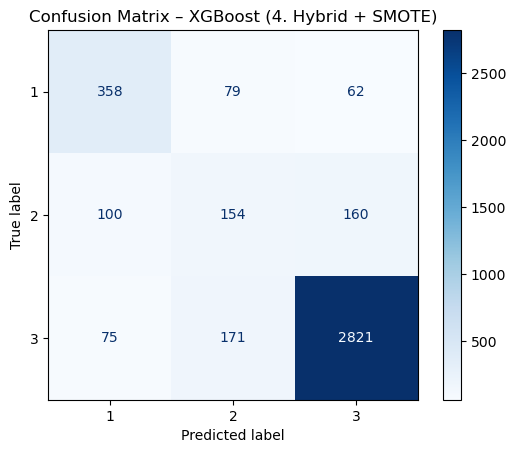

In [27]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(
    best_info["y_test"],
    best_info["preds"],
    labels=[0,1,2]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[1,2,3]
)

disp.plot(cmap="Blues", values_format="d")
plt.title(
    f"Confusion Matrix – {best_info['model_name']} ({best_info['comb_name']})"
)
plt.show()

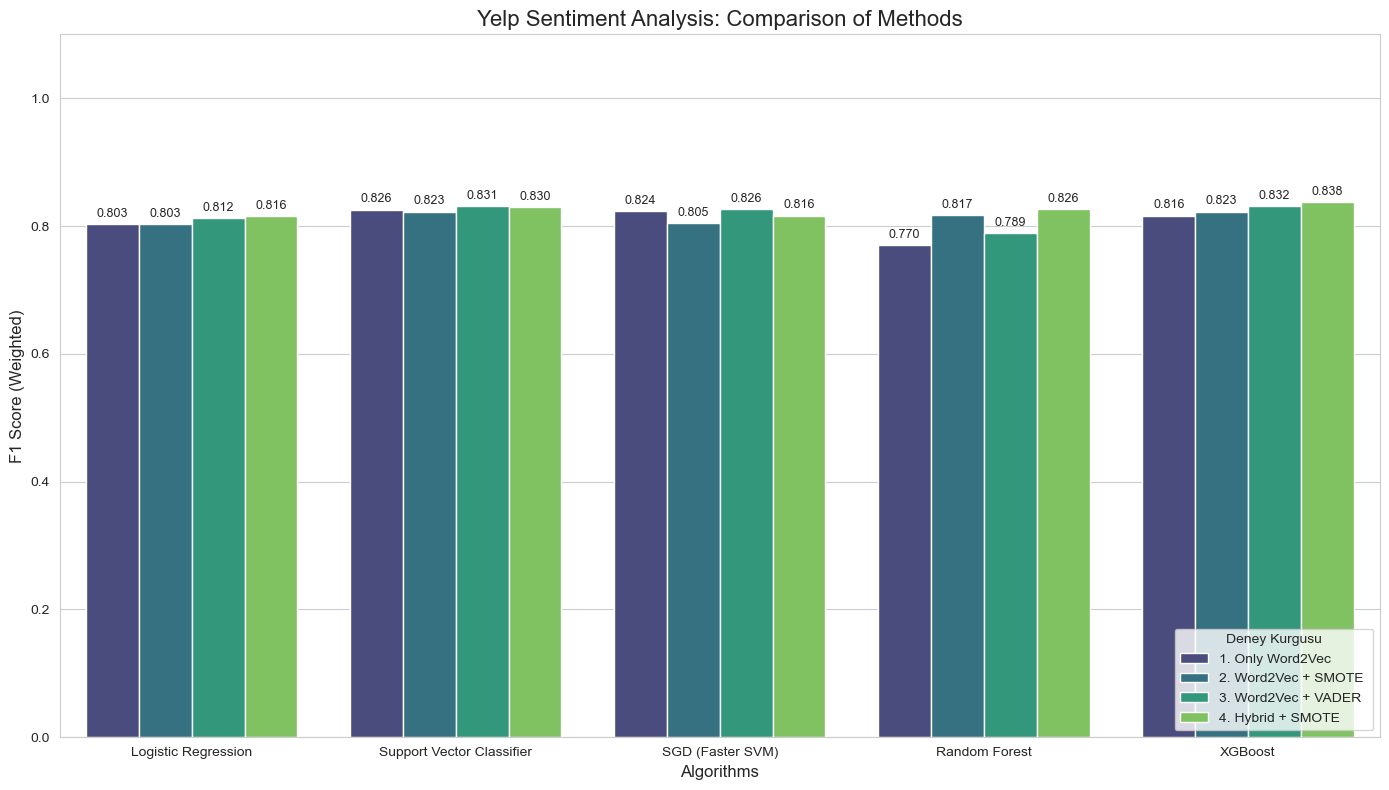

In [28]:
df_result = pd.DataFrame(results)

plt.figure(figsize=(14, 8))
sns.set_style("whitegrid")

ax = sns.barplot(
    data=df_result, 
    x="Model", 
    y="F1 Score", 
    hue="Combination", 
    palette="viridis"
)

plt.title("Yelp Sentiment Analysis: Comparison of Methods", fontsize=16)
plt.ylabel("F1 Score (Weighted)", fontsize=12)
plt.xlabel("Algorithms", fontsize=12)
plt.ylim(0, 1.1)
plt.legend(title="Deney Kurgusu", loc='lower right')

# Değerleri yaz
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=3, fontsize=9, rotation=0)

plt.tight_layout()
plt.show()

In [29]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

X_train, X_test, y_train, y_test = train_test_split(
    X_final,
    y_new,
    test_size = 0.2,
    stratify = y_new,
    random_state = 42
)

cv = StratifiedKFold(n_splits = 3, shuffle = True, random_state = 42)


pipe_xgb = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('model', xgb.XGBClassifier(objective='multi:softmax', num_class=3, random_state=42))
])

params_xgb = {
    'model__n_estimators': [100, 200, 300],
    'model__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'model__max_depth': [3, 5, 6],
    'model__subsample': [0.8, 1.0]
}

search_xgb = RandomizedSearchCV(
    pipe_xgb, 
    param_distributions=params_xgb,
    n_iter=15,
    cv=cv,
    scoring='f1_weighted',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

search_xgb.fit(X_train, y_train)

print(f"XGBoost En İyi Ayarlar: {search_xgb.best_params_}")
print(f"XGBoost En İyi CV Skoru: {search_xgb.best_score_:.4f}")
print("-" * 50)

Fitting 3 folds for each of 15 candidates, totalling 45 fits
XGBoost En İyi Ayarlar: {'model__subsample': 0.8, 'model__n_estimators': 200, 'model__max_depth': 6, 'model__learning_rate': 0.1}
XGBoost En İyi CV Skoru: 0.8375
--------------------------------------------------
